In [3]:
#pip install pandas numpy matplotlib seaborn scipy

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)
pd.set_option("display.max_columns", None)

In [5]:
df = pd.read_csv("weatherAUS.csv")
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [6]:
print("Dimensi data:", df.shape)
print("\nTipedata:")
print(df.dtypes)

print("\nInfo umum:")
df.info()

print("\nStatistik deskriptif (numerik):")
df.describe

print("\nStatistik deskriptif (kategorikal):")
df.describe(include="object")

# Cek missing value
print(df.isnull().sum())
print("\nTotal baris dengan minimal 1 missing value:", df.isnull().any(axis=1).sum())

#Cek duplikasi baris
print("Duplikat (termasuk, salah):", df.duplicated(["Date", "Location"]).sum())

#Cek inkonsistensi kolom kategorikal
print("Nilai unik pada 'Location':", df["Location"].dropna().unique())
print("Jumlah variasi:", df["Location"].dropna().nunique())
print("Nilai unik pada 'WindGustDir':", df["WindGustDir"].dropna().unique())
print("Jumlah variasi:", df["WindGustDir"].dropna().nunique())
print("Nilai unik pada 'WindDir9am':", df["WindDir9am"].dropna().unique())
print("Jumlah variasi:", df["WindDir9am"].dropna().nunique())
print("Nilai unik pada 'WindDir3pm':", df["WindDir3pm"].dropna().unique())
print("Jumlah variasi:", df["WindDir3pm"].dropna().nunique())
print("Nilai unik pada 'RainToday':", df["RainToday"].dropna().unique())
print("Jumlah variasi:", df["RainToday"].dropna().nunique())
print("Nilai unik pada 'RainTomorrow':", df["RainTomorrow"].dropna().unique())
print("Jumlah variasi:", df["RainTomorrow"].dropna().nunique())

#Cek rentang nilai wajar secara fisik untuk tiap fitur numerik
numeric_cols = ["MinTemp","MaxTemp","Rainfall","Evaporation","Sunshine",
                "WindGustSpeed", "WindSpeed9am","WindSpeed3pm","Humidity9am",
                "Humidity3pm","Pressure9am","Pressure3pm","Cloud9am","Cloud3pm",
                "Temp9am","Temp3pm"]
print(df[numeric_cols].describe())

Dimensi data: (145460, 23)

Tipedata:
Date                 str
Location             str
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir          str
WindGustSpeed    float64
WindDir9am           str
WindDir3pm           str
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday            str
RainTomorrow         str
dtype: object

Info umum:
<class 'pandas.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  str    
 1   Location       145460 non-null  str    
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null 

C:\Users\Daffi\AppData\Local\Temp\ipykernel_23448\2654237539.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


Date                 0
Location             0
MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation      62790
Sunshine         69835
WindGustDir      10326
WindGustSpeed    10263
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am      1767
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Cloud9am         55888
Cloud3pm         59358
Temp9am           1767
Temp3pm           3609
RainToday         3261
RainTomorrow      3267
dtype: int64

Total baris dengan minimal 1 missing value: 89040
Duplikat (termasuk, salah): 0
Nilai unik pada 'Location': <StringArray>
[          'Albury',    'BadgerysCreek',            'Cobar',
     'CoffsHarbour',            'Moree',        'Newcastle',
        'NorahHead',    'NorfolkIsland',          'Penrith',
         'Richmond',           'Sydney',    'SydneyAirport',
       'WaggaWagga',      'Williamtown',       'Wollongong',
         'Canberra',      'Tug

In [7]:
valid_ranges = {
    "MinTemp": (-15, 50),       # Derajat Celcius (Suhu ekstrem dingin dan panas di Australia)
    "MaxTemp": (-10, 60),       # Derajat Celcius
    "Rainfall": (0, 400),       # mm (Rentang 0-40 mm umum, tapi badai bisa mencapai 370+ mm)
    "Evaporation": (0, 40),     # mm (Di atas 40 mm per hari biasanya adalah error pencatatan)
    "Sunshine": (0, 15),        # Jam (Maksimal durasi matahari bersinar sehari ~14.5 jam)
    "WindGustSpeed": (0, 80),  # km/jam (Batas aman untuk mencakup angin topan/badai)
    "WindSpeed9am": (0, 80),   # km/jam
    "WindSpeed3pm": (0, 80),   # km/jam
    "Humidity9am": (0, 100),    # Persentase (%) mutlak antara 0 hingga 100
    "Humidity3pm": (0, 100),    # Persentase (%) mutlak antara 0 hingga 100
    "Pressure9am": (970, 1050), # hPa (Tekanan udara normal permukaan laut adalah ~1013 hPa)
    "Pressure3pm": (970, 1050), # hPa
    "Cloud9am": (0, 9),         # Skala Okta (0 = cerah, 8 = mendung total, 9 = terhalang kabut)
    "Cloud3pm": (0, 9),         # Skala Okta
    "Temp9am": (-15, 50),       # Derajat Celcius
    "Temp3pm": (-10, 50),       # Derajat Celcius
}

for col, (low, high) in valid_ranges.items():
  n_invalid = ((df[col]<low)|(df[col]>high)).sum()
  print(f"{col}: {n_invalid} nilai di luar rentang wajar ({low}-{high})")
  # Set nilai di luar rentang wajar sebagai missing, untuk ditangani konsisten di 3.4
  df.loc[(df[col]<low) | (df[col] > high), col] = np.nan

MinTemp: 0 nilai di luar rentang wajar (-15-50)
MaxTemp: 0 nilai di luar rentang wajar (-10-60)
Rainfall: 0 nilai di luar rentang wajar (0-400)
Evaporation: 96 nilai di luar rentang wajar (0-40)
Sunshine: 0 nilai di luar rentang wajar (0-15)
WindGustSpeed: 1368 nilai di luar rentang wajar (0-80)
WindSpeed9am: 4 nilai di luar rentang wajar (0-80)
WindSpeed3pm: 3 nilai di luar rentang wajar (0-80)
Humidity9am: 0 nilai di luar rentang wajar (0-100)
Humidity3pm: 0 nilai di luar rentang wajar (0-100)
Pressure9am: 0 nilai di luar rentang wajar (970-1050)
Pressure3pm: 0 nilai di luar rentang wajar (970-1050)
Cloud9am: 0 nilai di luar rentang wajar (0-9)
Cloud3pm: 0 nilai di luar rentang wajar (0-9)
Temp9am: 0 nilai di luar rentang wajar (-15-50)
Temp3pm: 0 nilai di luar rentang wajar (-10-50)


In [8]:
print("Missing value sebelum imputasi:\n", df.isnull().sum())

# 1. Drop missing value pada target prediksi (RainTomorrow)
df.dropna(subset=['RainTomorrow'], inplace=True)

# 2. Imputasi Numerik dengan Median (Robust terhadap outlier)
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# 3. Imputasi RainToday berdasarkan kolom Rainfall yang sudah terisi (Logis meteorologi)
df['RainToday'] = np.where(df['Rainfall'] > 1.0, 'Yes', 'No')

# 4. Imputasi kolom Kategorikal dengan Modus
categorical_cols = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm']
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing value setelah imputasi:\n", df.isnull().sum())

Missing value sebelum imputasi:
 Date                 0
Location             0
MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation      62886
Sunshine         69835
WindGustDir      10326
WindGustSpeed    11631
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am      1771
WindSpeed3pm      3065
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Cloud9am         55888
Cloud3pm         59358
Temp9am           1767
Temp3pm           3609
RainToday         3261
RainTomorrow      3267
dtype: int64

Missing value setelah imputasi:
 Date             0
Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm    

In [9]:
assert df.isnull().sum().sum() == 0, "Masih ada missing value!"
assert df.duplicated(["Date","Location"]).sum() == 0, "Masih ada duplikat!"
print("Data sudah bersih dan siap untuk tahap selection & Transformation.")

Data sudah bersih dan siap untuk tahap selection & Transformation.


In [10]:
# Kolom identifier
id_cols = ["Date", "Location"]

# Fitur numerik (sensor)
numeric_cols = [
    "MinTemp","MaxTemp","Rainfall","Evaporation","Sunshine",
    "WindGustSpeed", "WindSpeed9am","WindSpeed3pm","Humidity9am",
    "Humidity3pm","Pressure9am","Pressure3pm","Cloud9am","Cloud3pm",
    "Temp9am","Temp3pm"
]

# Fitur kategorikal
categorical_cols = ["WindGustDir","WindDir9am","WindDir3pm"]

# Target (SUDAH BERBENTUK LIST)
target_col = ["RainToday","RainTomorrow"]

# PERBAIKAN: Hapus kurung siku pada target_col
df_selected = df[numeric_cols + categorical_cols + target_col].copy()

df_selected.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,WindGustDir,WindDir9am,WindDir3pm,RainToday,RainTomorrow
0,13.4,22.9,0.6,4.8,8.5,44.0,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,5.0,16.9,21.8,W,W,WNW,No,No
1,7.4,25.1,0.0,4.8,8.5,44.0,4.0,22.0,44.0,25.0,1010.6,1007.8,5.0,5.0,17.2,24.3,WNW,NNW,WSW,No,No
2,12.9,25.7,0.0,4.8,8.5,46.0,19.0,26.0,38.0,30.0,1007.6,1008.7,5.0,2.0,21.0,23.2,WSW,W,WSW,No,No
3,9.2,28.0,0.0,4.8,8.5,24.0,11.0,9.0,45.0,16.0,1017.6,1012.8,5.0,5.0,18.1,26.5,NE,SE,E,No,No
4,17.5,32.3,1.0,4.8,8.5,41.0,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,W,ENE,NW,No,No


In [11]:
# Kolom identifier
id_cols = ["Date", "Location"]

# Fitur numerik (sensor)
numeric_cols = [
    "MinTemp","MaxTemp","Rainfall","Evaporation","Sunshine",
    "WindGustSpeed", "WindSpeed9am","WindSpeed3pm","Humidity9am",
    "Humidity3pm","Pressure9am","Pressure3pm","Cloud9am","Cloud3pm",
    "Temp9am","Temp3pm"
]

# Fitur kategorikal
categorical_cols = ["Location","WindGustDir","WindDir9am","WindDir3pm"]

# Target (SUDAH BERBENTUK LIST)
target_col = ["RainToday","RainTomorrow"]

# PERBAIKAN: Hapus kurung siku pada target_col
df_selected = df[numeric_cols + categorical_cols + target_col].copy()

df_selected.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,Location,WindGustDir,WindDir9am,WindDir3pm,RainToday,RainTomorrow
0,13.4,22.9,0.6,4.8,8.5,44.0,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,5.0,16.9,21.8,Albury,W,W,WNW,No,No
1,7.4,25.1,0.0,4.8,8.5,44.0,4.0,22.0,44.0,25.0,1010.6,1007.8,5.0,5.0,17.2,24.3,Albury,WNW,NNW,WSW,No,No
2,12.9,25.7,0.0,4.8,8.5,46.0,19.0,26.0,38.0,30.0,1007.6,1008.7,5.0,2.0,21.0,23.2,Albury,WSW,W,WSW,No,No
3,9.2,28.0,0.0,4.8,8.5,24.0,11.0,9.0,45.0,16.0,1017.6,1012.8,5.0,5.0,18.1,26.5,Albury,NE,SE,E,No,No
4,17.5,32.3,1.0,4.8,8.5,41.0,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,Albury,W,ENE,NW,No,No


In [12]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Membuat kanvas dengan 1 baris dan 2 kolom (berdampingan)
# fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# # 1. Grafik untuk RainToday (di sebelah kiri / index 0)
# sns.countplot(data=df_selected, x="RainToday", palette="Set2", ax=axes[0])
# axes[0].set_title("Distribusi Label RainToday")
# axes[0].set_xlabel("")
# axes[0].set_ylabel("Jumlah")

# # 2. Grafik untuk RainTomorrow (di sebelah kanan / index 1)
# sns.countplot(data=df_selected, x="RainTomorrow", palette="Set1", ax=axes[1])
# axes[1].set_title("Distribusi Label RainTomorrow")
# axes[1].set_xlabel("")
# axes[1].set_ylabel("Jumlah")

# # Menyesuaikan jarak antar grafik agar rapi
# plt.tight_layout()
# plt.show()

# # Menampilkan persentase persis di bawah grafik
# print("=== Persentase RainToday ===")
# print(df_selected["RainToday"].value_counts(normalize=True) * 100)

# print("\n=== Persentase RainTomorrow ===")
# print(df_selected["RainTomorrow"].value_counts(normalize=True) * 100)

In [13]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # PERBAIKAN 1: Ubah ukuran grid menjadi 4x4 (total 16 bingkai)
# fig, axes = plt.subplots(4, 4, figsize=(18, 12))
# axes = axes.flatten()

# hist_cols = [
#     "MinTemp", "MaxTemp", "Rainfall", "Evaporation", "Sunshine",
#     "WindGustSpeed", "WindSpeed9am", "WindSpeed3pm", "Humidity9am",
#     "Humidity3pm", "Pressure9am", "Pressure3pm", "Cloud9am", "Cloud3pm",
#     "Temp9am", "Temp3pm"
# ]

# for i, col in enumerate(hist_cols):
#     # PERBAIKAN 2: Menggunakan x= agar histogram tegak lurus (vertikal)
#     sns.histplot(x=df_selected[col], kde=True, ax=axes[i], color="steelblue")
#     axes[i].set_title(f"Distribusi {col}")

# plt.tight_layout()
# plt.show()

In [14]:
# fig, axes = plt.subplots(4,4,figsize=(16,18))
# axes = axes.flatten()

# for i, col in enumerate(hist_cols):
#   sns.boxplot(y=df_selected[col], ax=axes[i], color="salmon")
#   axes[i].set_title(f"Boxplot {col}")

# plt.tight_layout()
# plt.show()

# #deteksi outlier dengan metode IQR
# def detect_outliers_iqr(data, col):
#   Q1 = data[col].quantile(0.25)
#   Q3 = data[col].quantile(0.75)
#   IQR = Q3 - Q1
#   lower = Q1 - 1.5 * IQR
#   upper = Q3 + 1.5 * IQR
#   outliers = data[(data[col] < lower) | (data[col] > upper)]
#   return len(outliers),lower,upper

# for col in hist_cols:
#   n_out, low, up = detect_outliers_iqr(df_selected,col)
#   print(f"{col}: {n_out} outlier (batas: {low:.2f} - {up:.2f})")

In [15]:
# plt.figure(figsize=(18, 8))

# # PERBAIKAN: Gunakan dataset 'df' yang asli, BUKAN 'df_selected'
# sns.countplot(data=df, x="Location", palette="pastel")

# plt.title("Distribusi Jumlah Pengamatan Cuaca per Lokasi")
# plt.xticks(rotation=90) # Memutar nama kota agar tidak bertumpuk
# plt.xlabel("Lokasi (Stasiun Cuaca)")
# plt.ylabel("Jumlah")

# plt.tight_layout()
# plt.show()

In [16]:
# fig, axes = plt.subplots(4, 4, figsize=(16, 9))
# axes = axes.flatten()

# for i, col in enumerate(hist_cols):
#     sns.boxplot(data=df_selected, x="RainToday", y=col, ax=axes[i], palette="Set2")
#     axes[i].set_title(f"{col} vs RainToday")

# plt.tight_layout()
# plt.show()

In [17]:
# fig, axes = plt.subplots(4, 4, figsize=(16, 9))
# axes = axes.flatten()

# for i, col in enumerate(hist_cols):
#     sns.boxplot(data=df_selected, x="RainTomorrow", y=col, ax=axes[i], palette="Set2")
#     axes[i].set_title(f"{col} vs RainTomorrow")

# plt.tight_layout()
# plt.show()

In [18]:
# persentase_hujan = pd.crosstab(df["Location"], df["RainToday"], normalize="index") * 100
# print("Persentase RainToday per Lokasi:")
# print(persentase_hujan.head()) # Menggunakan .head() agar output tidak terlalu panjang

# # 2. Visualisasi Grafik
# plt.figure(figsize=(18, 8)) # Ukuran diperlebar menjadi 18x8 agar 49 kota muat
# sns.countplot(data=df, x="Location", hue="RainToday", palette="Set1")

# # Penyesuaian Judul dan Label
# plt.title("Distribusi Kondisi Hujan Hari Ini (RainToday) Berdasarkan Lokasi")
# plt.xlabel("Lokasi (Stasiun Cuaca)")
# plt.ylabel("Jumlah Hari")

# # Memutar teks nama kota 90 derajat agar tidak saling bertumpuk
# plt.xticks(rotation=90)

# plt.tight_layout()
# plt.show()

In [19]:
# persentase_hujan = pd.crosstab(df["Location"], df["RainTomorrow"], normalize="index") * 100
# print("Persentase RainTomorrow per Lokasi:")
# print(persentase_hujan.head()) # Menggunakan .head() agar output tidak terlalu panjang

# # 2. Visualisasi Grafik
# plt.figure(figsize=(18, 8)) # Ukuran diperlebar menjadi 18x8 agar 49 kota muat
# sns.countplot(data=df, x="Location", hue="RainTomorrow", palette="Set1")

# # Penyesuaian Judul dan Label
# plt.title("Distribusi Kondisi Hujan Hari Ini (RainTomorrow) Berdasarkan Lokasi")
# plt.xlabel("Lokasi (Stasiun Cuaca)")
# plt.ylabel("Jumlah Hari")

# # Memutar teks nama kota 90 derajat agar tidak saling bertumpuk
# plt.xticks(rotation=90)

# plt.tight_layout()
# plt.show()

In [20]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# corr_cols = hist_cols + ["RainToday", "RainTomorrow"]

# # 1. Buat tabel sementara khusus untuk korelasi
# df_corr = df_selected[corr_cols].copy()

# # 2. Ubah teks menjadi angka (Yes=1, No=0)
# df_corr["RainToday"] = df_corr["RainToday"].map({"No": 0, "Yes": 1})
# df_corr["RainTomorrow"] = df_corr["RainTomorrow"].map({"No": 0, "Yes": 1})

# # 3. Hitung matriks korelasinya
# corr_matrix = df_corr.corr()

# # 4. Visualisasikan dengan Heatmap
# plt.figure(figsize=(14, 10)) # Ukuran saya perbesar karena kolomnya ada 18 (16 sensor + 2 rain)
# sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
# plt.title("Correlation Heatmap Sensor Cuaca vs Hujan")
# plt.tight_layout()
# plt.show()

In [21]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# sns.pairplot(
#    data=df_selected,
#    vars=["Humidity3pm", "Pressure3pm", "MinTemp", "MaxTemp"], # 4 fitur cuaca utama
#    hue="RainToday", # Mewarnai titik berdasarkan apakah besok hujan atau tidak
#     palette="Set2",
#     diag_kind="kde",
#     plot_kws={"alpha": 0.5, "s": 15}
# )
# plt.suptitle("Pairplot Fitur Utama Cuaca vs Hujan Hari Ini (RainToday)", y=1.02)
# plt.show()

In [22]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# sns.pairplot(
#    data=df_selected,
#    vars=["Humidity3pm", "Pressure3pm", "MinTemp", "MaxTemp"], # 4 fitur cuaca utama
#    hue="RainTomorrow", # Mewarnai titik berdasarkan apakah besok hujan atau tidak
#     palette="Set2",
#     diag_kind="kde",
#     plot_kws={"alpha": 0.5, "s": 15}
# )
# plt.suptitle("Pairplot Fitur Utama Cuaca vs Hujan Besok (RainTomorrow)", y=1.02)
# plt.show()

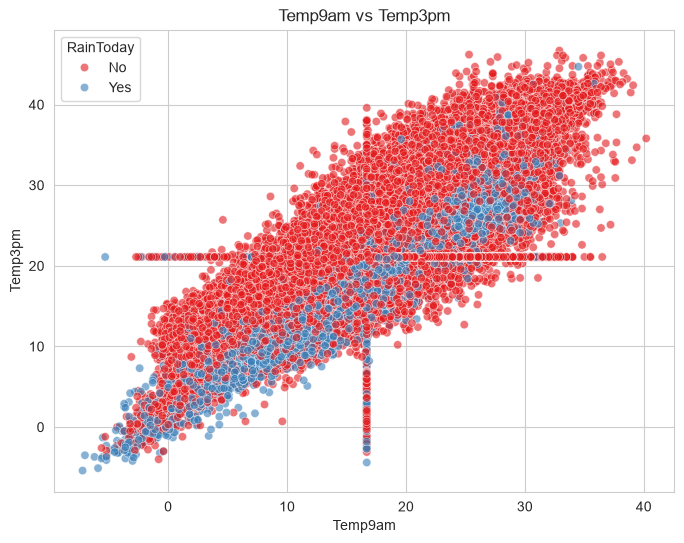

In [23]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_selected,
    x="Temp9am",
    y="Temp3pm",
    hue="RainToday",
    alpha=0.6,
    palette="Set1"
)
plt.title("Temp9am vs Temp3pm")
plt.show()

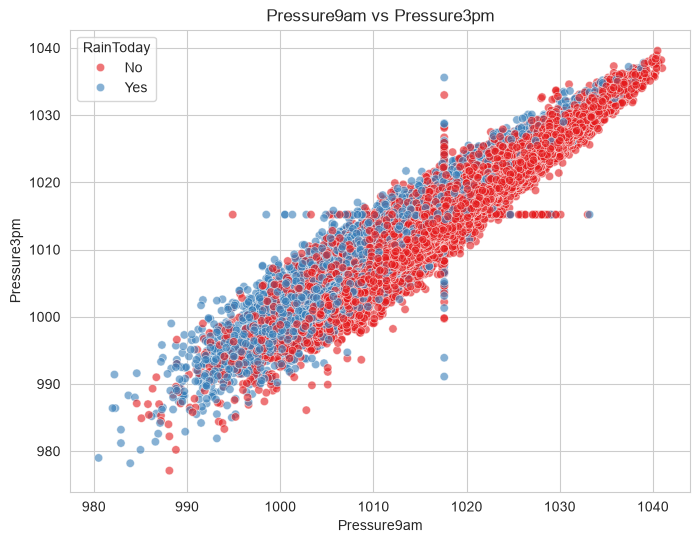

In [24]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_selected,
    x="Pressure9am",
    y="Pressure3pm",
    hue="RainToday",
    alpha=0.6,
    palette="Set1"
)
plt.title("Pressure9am vs Pressure3pm")
plt.show()

C:\Users\Daffi\AppData\Local\Temp\ipykernel_23448\735569873.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_selected, x="WindGustDir", order=compass_order, ax=axes[0], palette="Blues")
C:\Users\Daffi\AppData\Local\Temp\ipykernel_23448\735569873.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_selected, x="WindDir9am", order=compass_order, ax=axes[1], palette="Greens")
C:\Users\Daffi\AppData\Local\Temp\ipykernel_23448\735569873.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_selected, x="WindDir3pm"

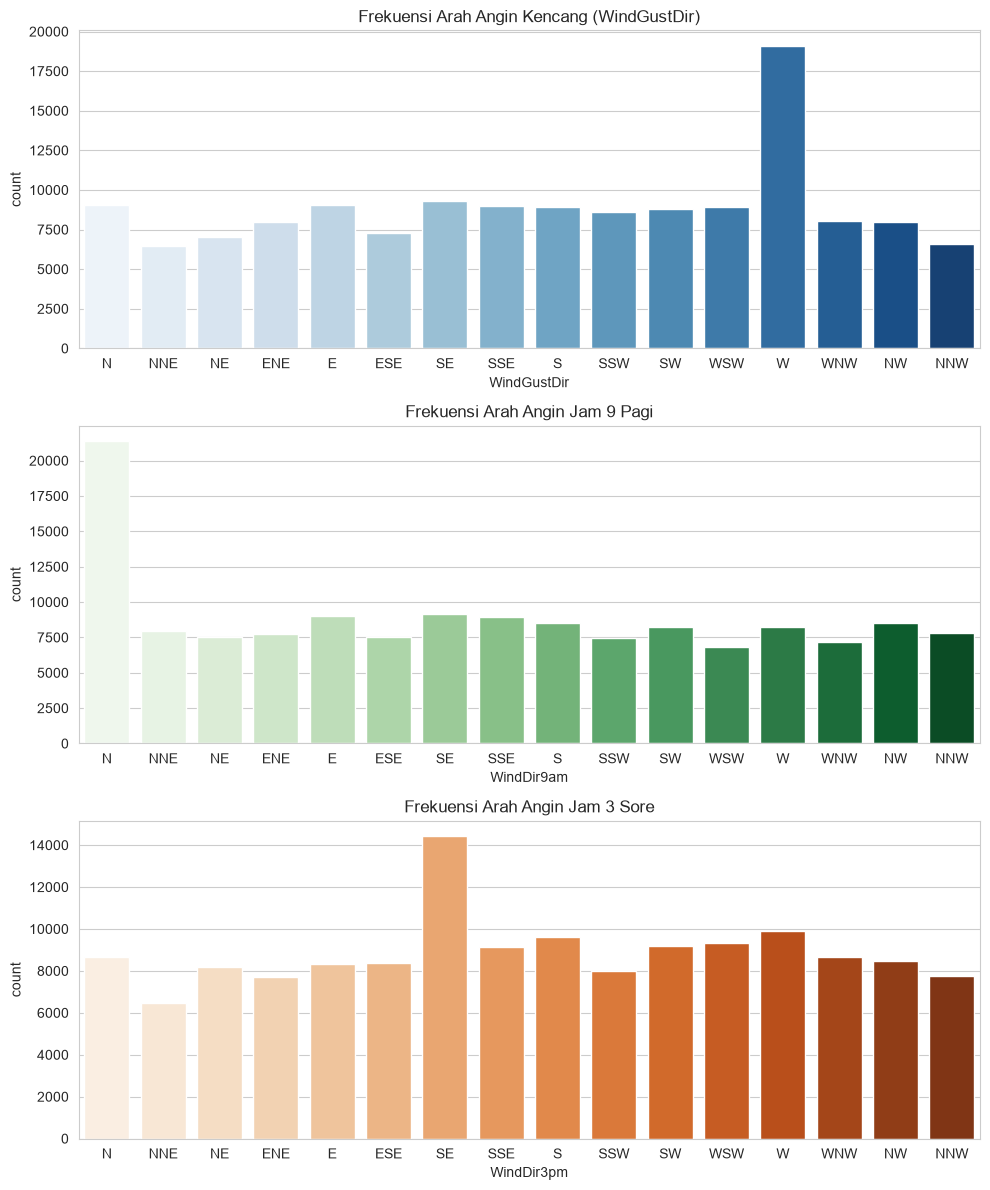

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

# Membuat urutan kompas agar grafiknya rapi (Utara searah jarum jam)
compass_order = ['N', 'NNE', 'NE', 'ENE', 'E', 'ESE', 'SE', 'SSE',
                 'S', 'SSW', 'SW', 'WSW', 'W', 'WNW', 'NW', 'NNW']

sns.countplot(data=df_selected, x="WindGustDir", order=compass_order, ax=axes[0], palette="Blues")
axes[0].set_title("Frekuensi Arah Angin Kencang (WindGustDir)")

sns.countplot(data=df_selected, x="WindDir9am", order=compass_order, ax=axes[1], palette="Greens")
axes[1].set_title("Frekuensi Arah Angin Jam 9 Pagi")

sns.countplot(data=df_selected, x="WindDir3pm", order=compass_order, ax=axes[2], palette="Oranges")
axes[2].set_title("Frekuensi Arah Angin Jam 3 Sore")

plt.tight_layout()
plt.show()

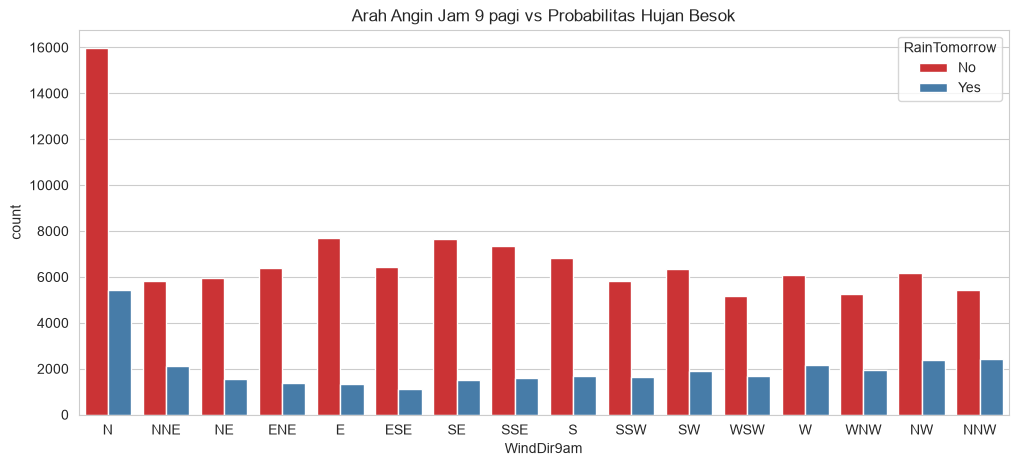

In [26]:
plt.figure(figsize=(12, 5))
sns.countplot(
    data=df_selected,
    x="WindDir9am",
    hue="RainTomorrow",
    order=compass_order,
    palette="Set1"
)
plt.title("Arah Angin Jam 9 pagi vs Probabilitas Hujan Besok")
plt.show()

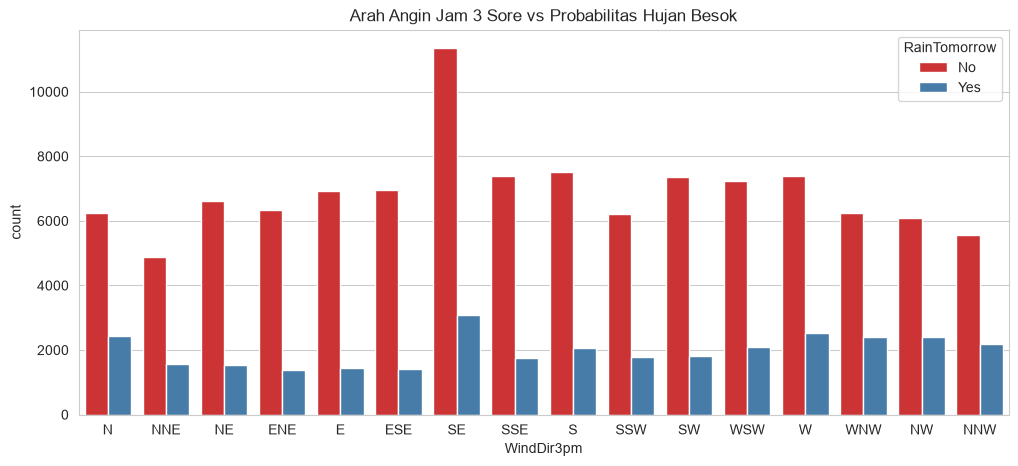

In [27]:
plt.figure(figsize=(12, 5))
sns.countplot(
    data=df_selected,
    x="WindDir3pm",
    hue="RainTomorrow",
    order=compass_order,
    palette="Set1"
)
plt.title("Arah Angin Jam 3 Sore vs Probabilitas Hujan Besok")
plt.show()

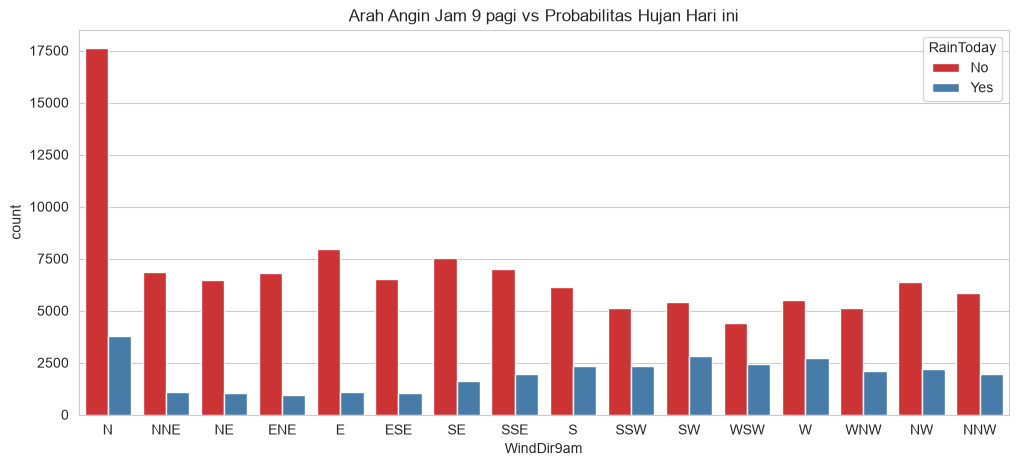

In [28]:
plt.figure(figsize=(12, 5))
sns.countplot(
    data=df_selected,
    x="WindDir9am",
    hue="RainToday",
    order=compass_order,
    palette="Set1"
)
plt.title("Arah Angin Jam 9 pagi vs Probabilitas Hujan Hari ini")
plt.show()

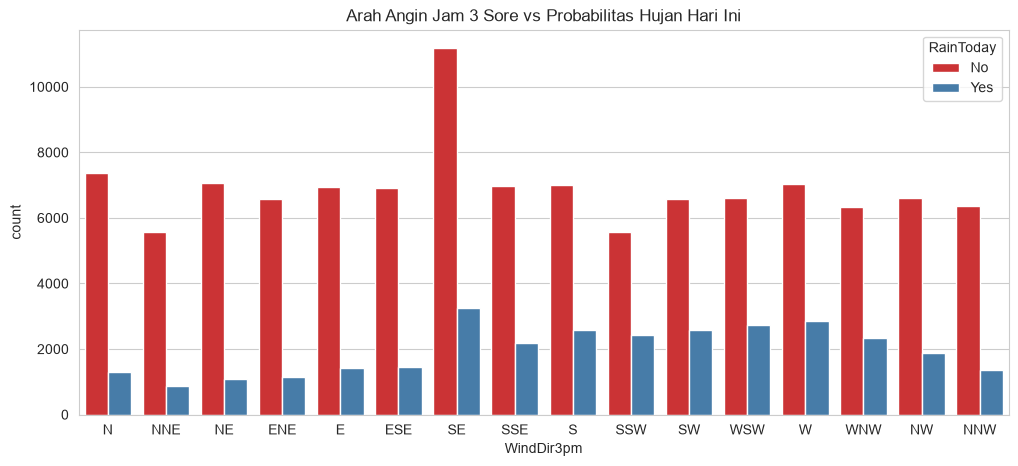

In [29]:
plt.figure(figsize=(12, 5))
sns.countplot(
    data=df_selected,
    x="WindDir3pm",
    hue="RainToday",
    order=compass_order,
    palette="Set1"
)
plt.title("Arah Angin Jam 3 Sore vs Probabilitas Hujan Hari Ini")
plt.show()

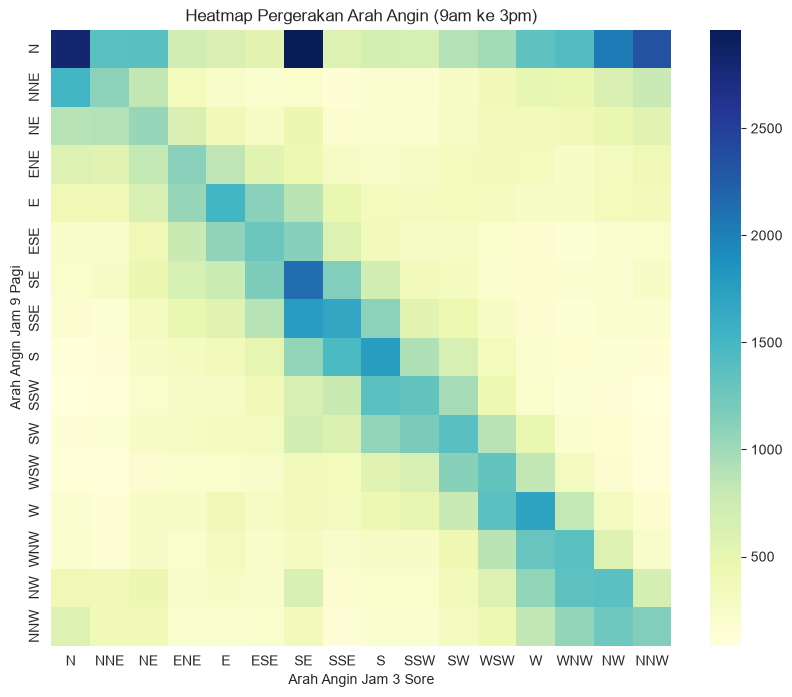

In [30]:
# Membuat tabel silang antara arah angin pagi vs sore
wind_shift = pd.crosstab(df_selected['WindDir9am'], df_selected['WindDir3pm'])

# Mengurutkan baris dan kolom sesuai arah jarum jam kompas
wind_shift = wind_shift.reindex(index=compass_order, columns=compass_order)

plt.figure(figsize=(10, 8))
sns.heatmap(wind_shift, cmap="YlGnBu", annot=False) # annot=False agar angka tidak menumpuk
plt.title("Heatmap Pergerakan Arah Angin (9am ke 3pm)")
plt.xlabel("Arah Angin Jam 3 Sore")
plt.ylabel("Arah Angin Jam 9 Pagi")
plt.show()

In [31]:
# Buang kolom bantu yang hanya dipakai untuk visualisasi (opsional, sesuaikan kebutuhan)
# Pastikan variabel df_selected sudah didefinisikan di sel sebelumnya agar tidak error

# Menyimpan file langsung ke folder lokal VS Code Anda
df_selected.to_csv("weatherAUS_ready.csv", index=False)

print("Berhasil! File weatherAUS_ready.csv sudah tersimpan di folder Anda.")

# Menampilkan 5 baris pertama untuk memastikan data sudah sesuai
df_selected.head()

Berhasil! File weatherAUS_ready.csv sudah tersimpan di folder Anda.


,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,Location,WindGustDir,WindDir9am,WindDir3pm,RainToday,RainTomorrow
0,13.4,22.9,0.6,4.8,8.5,44.0,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,5.0,16.9,21.8,Albury,W,W,WNW,No,No
1,7.4,25.1,0.0,4.8,8.5,44.0,4.0,22.0,44.0,25.0,1010.6,1007.8,5.0,5.0,17.2,24.3,Albury,WNW,NNW,WSW,No,No
2,12.9,25.7,0.0,4.8,8.5,46.0,19.0,26.0,38.0,30.0,1007.6,1008.7,5.0,2.0,21.0,23.2,Albury,WSW,W,WSW,No,No
3,9.2,28.0,0.0,4.8,8.5,24.0,11.0,9.0,45.0,16.0,1017.6,1012.8,5.0,5.0,18.1,26.5,Albury,NE,SE,E,No,No
4,17.5,32.3,1.0,4.8,8.5,41.0,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,Albury,W,ENE,NW,No,No
